# WESM Price Prediction - Model 3: Neural Network

## Setup and Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15260 entries, 0 to 15259
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            15260 non-null  datetime64[ns]
 1   GWAP                15260 non-null  float64       
 2   energy_demand_mw    15260 non-null  float64       
 3   energy_supply_mw    15260 non-null  float64       
 4   energy_shortage_mw  15260 non-null  float64       
 5   reserve_demand_mw   15260 non-null  float64       
 6   reserve_supply_mw   15260 non-null  float64       
 7   outage_count        15260 non-null  float64       
 8   GWAP_Lag_1          15260 non-null  float64       
 9   GWAP_Lag_12         15260 non-null  float64       
 10  GWAP_Lag_288        15260 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 1.3 MB
None


First we need to ensure consistency across all data types to be able to use Tensor later on. So, we will convert the `month_year` feature into a datetime variable and separate them into two categories: `month` and `year`.

In [2]:
df["month_year"] = df["datetime"].dt.to_period("M").astype(str)

# Convert string to datetime
df['date_col'] = pd.to_datetime(df['month_year'], format='%Y-%m')

df['year'] = df['date_col'].dt.year
df['month'] = df['date_col'].dt.month

`X_gwap` will contain all the features aside from `GWAP` and `gwap_range` as those will serve as our label. Time-based columns are also dropped since we have already made separate columns for `year` and `month`. `y_gwap` will contain the **GWAP** and serve as our label.

In [3]:
# remove datetime since we already have separate columns
X_gwap = df.drop(["GWAP", "datetime", "month_year", "date_col", "energy_shortage_mw"], axis=1)

# Transforms the class variable into a matrix of shape (n_samples, 1)
y_gwap = df["GWAP"].values

X_gwap.head()

,energy_demand_mw,energy_supply_mw,reserve_demand_mw,reserve_supply_mw,outage_count,GWAP_Lag_1,GWAP_Lag_12,GWAP_Lag_288,year,month
0,8549.80,8592.66,1368.0,1368.0,3.0,3127.6873,2528.3538,2321.6376,2025,11
1,8502.47,8621.92,1368.0,1368.0,3.0,2590.3569,2534.1721,2394.5301,2025,11
2,8503.43,8621.24,1368.0,1368.0,3.0,2379.0282,2484.7641,2325.4293,2025,11
3,8446.04,8586.57,1368.0,1368.0,3.0,2378.7328,2720.1748,2320.9318,2025,11
4,8474.76,8589.58,1368.0,1368.0,3.0,2378.4848,2756.0153,2314.6513,2025,11


In [4]:
y_gwap

array([2590.3569, 2379.0282, 2378.7328, ..., 2831.0809, 2830.2625,
       2730.0929], shape=(15260,))

---

## Splitting the Data

Dividing the dataset into training set, validation set, and test set. The **test set** and **validation set** will contain 15% of the original dataset, while the **training set** will contain 70%.

In [5]:
from sklearn.model_selection import train_test_split

# Separate the test set from the train and validation sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_gwap,
    y_gwap,
    test_size=0.15,
    random_state=1,
    shuffle=True
)

# Separate the validation set from the train set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.17647,  # 15% of leftover data
    random_state=1,
    shuffle=True
)

In [6]:
print("Size of training set: ", X_train.shape)
print("Size of validation set: ", X_val.shape)
print("Size of test set: ", X_test.shape)

Size of training set:  (10682, 10)
Size of validation set:  (2289, 10)
Size of test set:  (2289, 10)


---

## Standardizing the Data

Since we are working with high-magnitude values, we will standardize our data to lessen the probability of overshooting. We will only fit on training data to prevent data leakage.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
X_test = scaler_X.transform(X_test)
X_val = scaler_X.transform(X_val)  

In [8]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
y_test = scaler_y.transform(y_test.reshape(-1, 1))
y_val = scaler_y.transform(y_val.reshape(-1, 1))

---

## Converting to Tensor

Convert the np.ndarrays to datatype torch.Tensor

In [9]:
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_val = torch.Tensor(X_val)
y_val = torch.Tensor(y_val)

---

## Setting up the Neural Network

*Hyperparameter tuning to be done later, this is just to see how it works with a random model

First, we import the NeuralNetwork class

In [10]:
from neural_network import NeuralNetwork

The model we will use will have the following parameters:
- `input_size`: 11 features
- `hidden_layers`: [64, 32]
- `output_size`: 1
- `activation`: relu

We are creating a Neural Network that takes in **11 features** with **2 hidden layers**, where there are **64 neurons** in the first hidden layer and **32 neurons** in the second hidden layer.

Since we are using **regression**, there will only be 1 output neuron. The activation function we will use for the hidden layers is **reLu**.

In [11]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [64, 32]      # to be tuned
output_size = 1

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation='relu')

We then create the network and initialize the weights

In [12]:
model.create_network()
model.init_weights()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


---

## Setting the Loss Function and Optimizer

This model will use **MSE** for evaluation and **Adam** as the optimizer with a learning rate of **0.001**.

In [13]:
# used for regression
criterion = nn.MSELoss()  
learning_rate = 0.001      
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

---

## Training

The training pipeline follows the typical progression of a neural network.

1. Empty the gradients of the network.
2. Forward propagation
3. Compute the loss
4. Backward propagation
5. Update parameters

We will use mini-batch gradient descent to train our model. We will use our Dataloader object to handle batch segragation and pass **32** as our batch size.

In [14]:
from data_laoder import DataLoader

batch_size = 32  # to be tuned
data_loader = DataLoader(X_train, y_train, batch_size)

We will have a maximum epoch of **400**. We will also check if the values are converging, determined if the difference in loss of each epoch is less than **0.00005**

`Note`: `model(X)` is called instead of `model.forward` since it automatically calls the forward method with gradient tracking, hooks, distributed training support, and mixed precision support.

In [15]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.313756
Epoch: 20 	Loss: 0.151637
Epoch: 40 	Loss: 0.138964
Epoch: 60 	Loss: 0.133170
Epoch: 80 	Loss: 0.129496
Epoch: 100 	Loss: 0.124812
Epoch: 120 	Loss: 0.122658
Epoch: 140 	Loss: 0.120781
Epoch: 160 	Loss: 0.118803
Epoch: 180 	Loss: 0.116088
Epoch: 200 	Loss: 0.112418
Epoch: 220 	Loss: 0.112182
Epoch: 240 	Loss: 0.109708
Epoch: 260 	Loss: 0.108752
Epoch: 280 	Loss: 0.108922
Epoch: 300 	Loss: 0.105736
Epoch: 320 	Loss: 0.103461
Epoch: 340 	Loss: 0.102983
Epoch: 360 	Loss: 0.104297
Epoch: 380 	Loss: 0.101634
Epoch: 400 	Loss: 0.099117


In [16]:
#epochs = 201   # to be tuned
#train_losses = []
#val_losses = []
#is_converged = False
#
## TODO: implement mini-batch gradient descent and convergence check
#for epoch in range(epochs):
#    model.train()
#
#    # Empty the gradients of the network.
#    optimizer.zero_grad()
#    
#    # Forward propagation
#    y_pred = model(X_train) # calls the forward method but adding gradient tracking, hooks, extra support
#    
#    # Compute the loss
#    loss = criterion(y_pred, y_train)
#    
#    # Backward propagation
#    loss.backward()
#
#    # Update parameters
#    optimizer.step()
#    
#    # Validation
#    model.eval()
#    with torch.no_grad():
#        y_val_pred = model(X_val)
#        val_loss = criterion(y_val_pred, y_val)
#
#    train_losses.append(loss.item())
#    val_losses.append(val_loss.item())
#    
#    if epoch % 20 == 0:
#        print(f"Epoch {epoch}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

### Loss for Each Epoch 

Text(0.5, 1.0, 'Loss for each epoch')

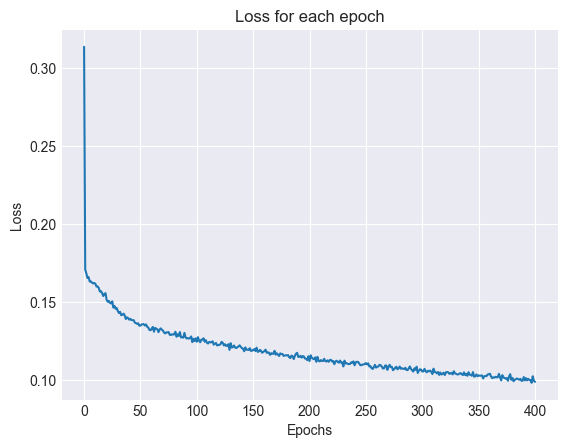

In [17]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

---

## Evaluating on Test Data

We will now test the performance of our model on the **Test set**. 

`Notes`:
- We use `torch.no_grad`, which disables gradient calculation, since we will **not** be doing backwards propagation when evaluating on the test set.
- Since we standardized our data earlier, we use `scaler_y.inverse_transform` to return the values to its original scale.

In [18]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

# inverse-transform the predictions to get them back to the original scale
y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_original = scaler_y.inverse_transform(y_test.numpy())

In [19]:
test_loss = criterion(y_pred_test, y_test)
print(test_loss)

tensor(0.2136)


### Visualization

Now, let us compare the model's predictions against the actual values using a scatter plot.

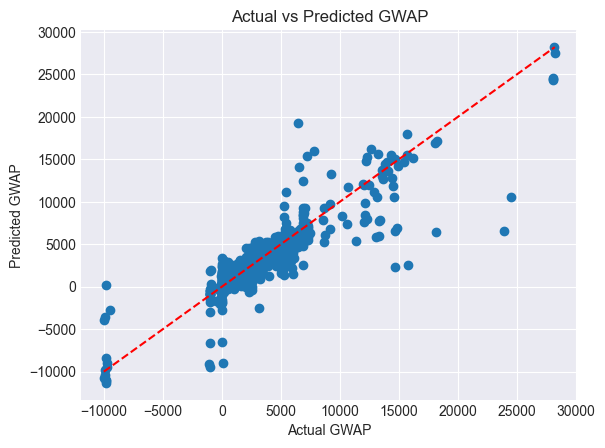

In [20]:
plt.scatter(y_test_original, y_pred_original)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)],
         'r--')  # perfect prediction line
plt.show()

*analysis and conclusion to be added

---

## Hyperparameter Tuning

Our current lowest loss is **0.0916** after training on 400 epochs. We will implement hyperparameter tuning on the following parameters in an attempt to better our current model.

Selected parameters to be tuned:

- hidden_layers = [[32], [64], [128], [32,32], [64,64], [128,128], [32, 32, 32], [64, 64, 64]]
- learning_rates = [0.01, 0.001]
- batch_sizes = [32, 64]
- activation = ['relu', 'tanh']

In [33]:
hidden_layers = [[32], [64], [128], [32,32], [64,64], [128,128], [32, 32, 32], [64, 64, 64]]
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64, 128]
activation = ['relu', 'tanh']

In [34]:
def train_and_evaluate(model, optimizer, batch_size):

    criterion = nn.MSELoss()

    # Validation evaluation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    return val_loss.item()

In [35]:
results = []
best_loss = float('inf')
best_params = None
input_size = X_train.shape[1]

for hidden in hidden_layers:
    for lr in learning_rates:
        for batch in batch_sizes:
            for act in activation:

                print(f"Testing: layers={hidden}, lr={lr}, batch={batch}, act={act}")

                model = NeuralNetwork(
                    input_size=input_size,
                    num_outputs=1,
                    list_hidden=hidden,
                    activation=act
                )

                model.create_network()
                model.init_weights()

                optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                val_loss = train_and_evaluate(model, optimizer, batch)

                print(f"Validation Loss: {val_loss:.4f}")

                results.append({
                    "hidden_layers": hidden,
                    "learning_rate": lr,
                    "batch_size": batch,
                    "activation": act,
                    "val_loss": val_loss
                })

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_params = results[-1]

print("Best Parameters:")
print(best_params)

Testing: layers=[32], lr=0.01, batch=32, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.01, batch=32, act=tanh
Validation Loss: 1.1154
Testing: layers=[32], lr=0.01, batch=64, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.01, batch=64, act=tanh
Validation Loss: 1.1154
Testing: layers=[32], lr=0.01, batch=128, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.01, batch=128, act=tanh
Validation Loss: 1.1154
Testing: layers=[32], lr=0.001, batch=32, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.001, batch=32, act=tanh
Validation Loss: 1.1154
Testing: layers=[32], lr=0.001, batch=64, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.001, batch=64, act=tanh
Validation Loss: 1.1154
Testing: layers=[32], lr=0.001, batch=128, act=relu
Validation Loss: 1.0613
Testing: layers=[32], lr=0.001, batch=128, act=tanh
Validation Loss: 1.1154
Testing: layers=[64], lr=0.01, batch=32, act=relu
Validation Loss: 1.0836
Testing: layers=[64], lr=0.0

---

## Updating the Model

In [36]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [32, 32, 32]     
output_size = 1
activation = 'tanh'

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation=activation)

In [37]:
model.create_network()
model.init_weights()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [38]:
# used for regression
criterion = nn.MSELoss()  
learning_rate = 0.01      
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [39]:
from data_laoder import DataLoader

batch_size = 32 
data_loader = DataLoader(X_train, y_train, batch_size)

In [40]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.298956
Epoch: 20 	Loss: 0.199821
Epoch: 40 	Loss: 0.212329
Epoch: 60 	Loss: 0.221691
Epoch: 80 	Loss: 0.230703
Epoch: 100 	Loss: 0.202766
Epoch: 120 	Loss: 0.188437
Epoch: 140 	Loss: 0.192518
Epoch: 160 	Loss: 0.199575
Epoch: 180 	Loss: 0.195937
Epoch: 200 	Loss: 0.203701
Epoch: 220 	Loss: 0.214178
Epoch: 240 	Loss: 0.193817
Epoch: 260 	Loss: 0.199785
Epoch: 280 	Loss: 0.195981
Epoch: 300 	Loss: 0.185871
Epoch: 320 	Loss: 0.175480
Epoch: 340 	Loss: 0.187836
Epoch: 360 	Loss: 0.189840
Epoch: 380 	Loss: 0.174898
Epoch: 400 	Loss: 0.179907


Text(0.5, 1.0, 'Loss for each epoch')

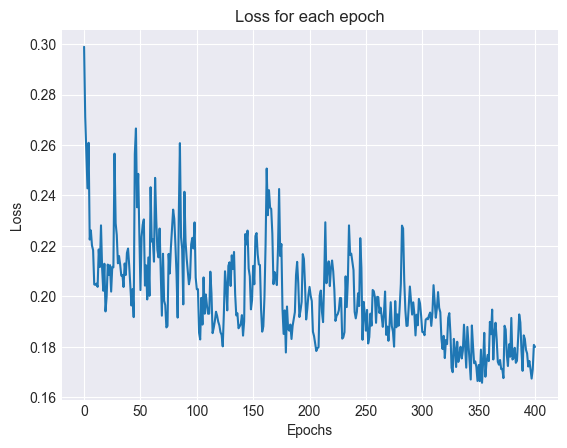

In [41]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

In [42]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

# inverse-transform the predictions to get them back to the original scale
y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_original = scaler_y.inverse_transform(y_test.numpy())

In [43]:
test_loss = criterion(y_pred_test, y_test)
print(test_loss)

tensor(0.1993)


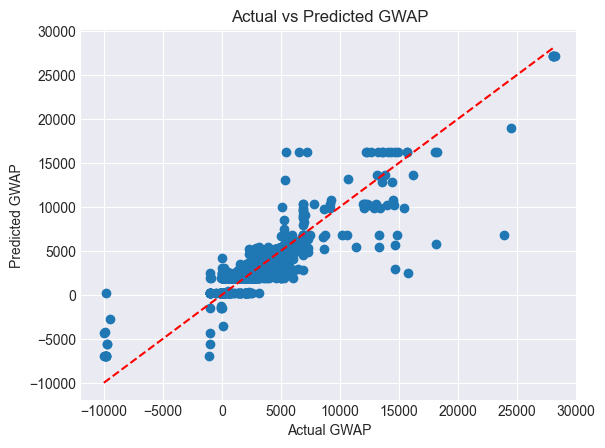

In [44]:
plt.scatter(y_test_original, y_pred_original)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)],
         'r--')  # perfect prediction line
plt.show()